# AnalystLab Africa — Week 2 Assignment
## Feature Engineering & Data Preprocessing for Machine Learning
### Loan Prediction Dataset

**Objective:** Prepare the Loan Prediction training dataset for machine learning by inspecting, cleaning, engineering, encoding, scaling, detecting/treating outliers, and selecting useful features.

**Target variable:** `Loan_Status`
- `Y` = approved
- `N` = not approved


## 1. Business Understanding

The business problem is to prepare historical loan application data for a predictive modelling task that estimates whether a loan application is likely to be approved.

The project objective is to transform the raw application data into a consistent machine-learning-ready format while documenting the preprocessing decisions.

Predictive modelling can support more consistent and efficient loan screening by using information available in an application to estimate the likely approval outcome. The expected business impact is improved decision support, better data quality, and a repeatable preprocessing workflow for future modelling.


## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)


## 3. Load the Dataset

In [2]:
train = pd.read_csv("../data/train_loan_prediction.csv")
test = pd.read_csv("../data/test_loan_prediction.csv")

print("Training dataset shape:", train.shape)
print("Test dataset shape:", test.shape)
display(train.head(10))


Training dataset shape: (614, 13)
Test dataset shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


## 4. Dataset Inspection

In [3]:
print("Rows and columns:", train.shape)
print("\nData types:")
display(train.dtypes.to_frame("data_type"))

print("\nMissing values:")
display(train.isna().sum().to_frame("missing_values"))

print("\nDuplicate records:", train.duplicated().sum())

print("\nSummary statistics:")
display(train.describe(include="all").T)


Rows and columns: (614, 13)

Data types:


,data_type
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Missing values:


,missing_values
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14



Duplicate records: 0

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


## 5. Target Variable

In [4]:
print(train["Loan_Status"].value_counts())
print("\nPercentage distribution:")
display((train["Loan_Status"].value_counts(normalize=True) * 100).round(2))


Loan_Status
Y    422
N    192
Name: count, dtype: int64

Percentage distribution:


Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64

## 6. Data Cleaning and Feature Engineering

Cleaning decisions:
1. Remove duplicate rows if present.
2. Standardize `Dependents` by converting `3+` to `3`.
3. Remove `Loan_ID` because it is an identifier rather than a meaningful predictive feature.
4. Rename columns to clear snake_case names.
5. Create `total_income` from applicant income plus coapplicant income.
6. Treat `Credit_History` and `Loan_Amount_Term` as discrete categorical variables for encoding.
7. Fill missing categorical values with the mode and continuous numerical values with the median.


In [5]:
df = train.drop_duplicates().copy()

df["Dependents"] = df["Dependents"].replace({"3+": "3"})

df = df.rename(columns={
    "Loan_ID":"loan_id", "Gender":"gender", "Married":"married",
    "Dependents":"dependents", "Education":"education",
    "Self_Employed":"self_employed", "ApplicantIncome":"applicant_income",
    "CoapplicantIncome":"coapplicant_income", "LoanAmount":"loan_amount",
    "Loan_Amount_Term":"loan_amount_term", "Credit_History":"credit_history",
    "Property_Area":"property_area", "Loan_Status":"loan_status"
})

df = df.drop(columns=["loan_id"])
df["total_income"] = df["applicant_income"] + df["coapplicant_income"]

categorical_cols = [
    "gender", "married", "dependents", "education",
    "self_employed", "property_area", "loan_amount_term", "credit_history"
]
continuous_cols = [
    "applicant_income", "coapplicant_income", "loan_amount", "total_income"
]

df["loan_amount_term"] = df["loan_amount_term"].astype("Int64").astype("string")
df["credit_history"] = df["credit_history"].astype("Int64").astype("string")

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in continuous_cols:
    df[col] = df[col].fillna(df[col].median())

print("Shape after cleaning:", df.shape)
print("\nRemaining missing values:", int(df.isna().sum().sum()))
display(df.head())


Shape after cleaning: (614, 13)

Remaining missing values: 0


,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status,total_income
0,Male,No,0,Graduate,No,5849,0.0,128.0,360,1,Urban,Y,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360,1,Rural,N,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360,1,Urban,Y,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360,1,Urban,Y,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360,1,Urban,Y,6000.0


## 7. Outlier Detection and Treatment

In [6]:
outlier_counts = {}

for col in continuous_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

    # Cap extreme values rather than deleting observations.
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers detected before IQR capping:")
display(pd.Series(outlier_counts, name="outlier_count"))


Outliers detected before IQR capping:


applicant_income      50
coapplicant_income    18
loan_amount           41
total_income          50
Name: outlier_count, dtype: int64

## 8. Visualizations

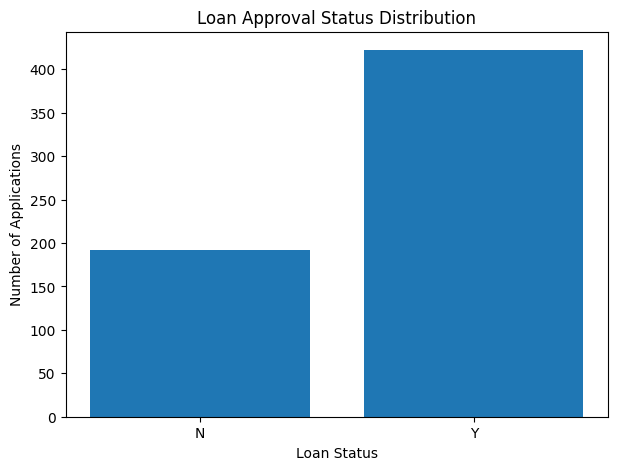

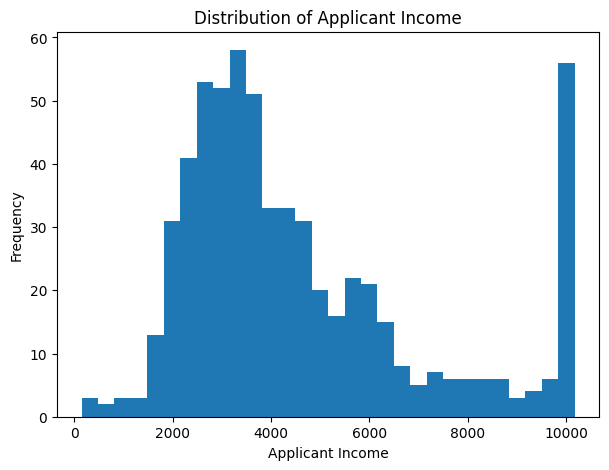

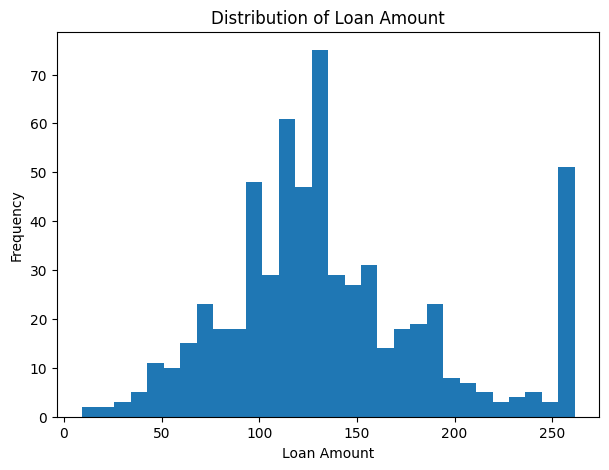

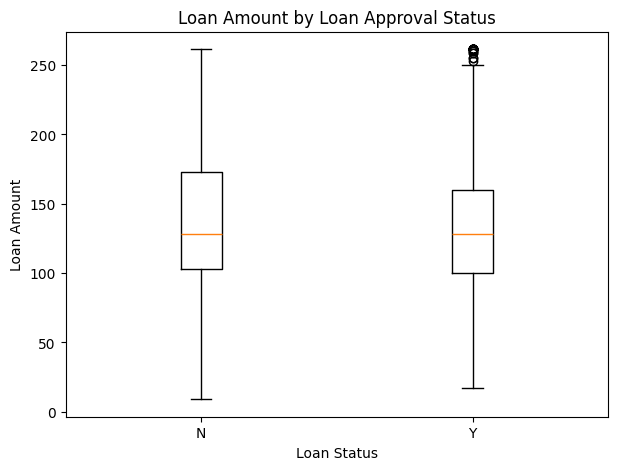

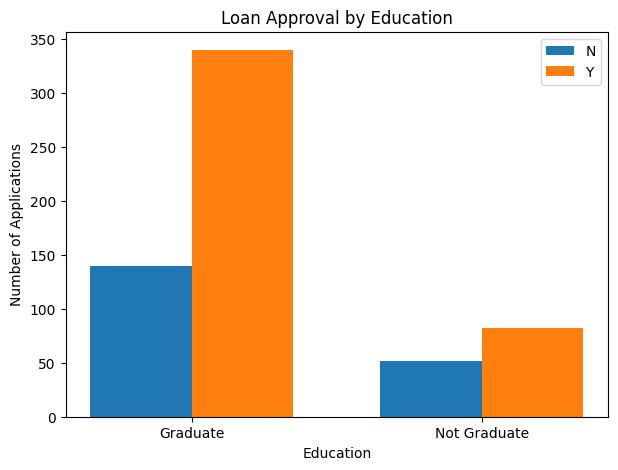

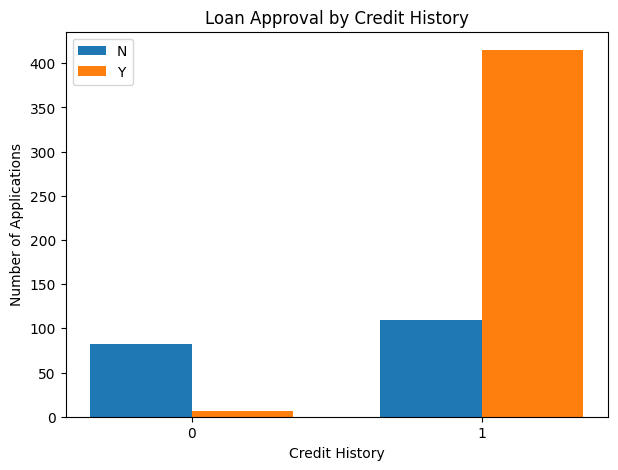

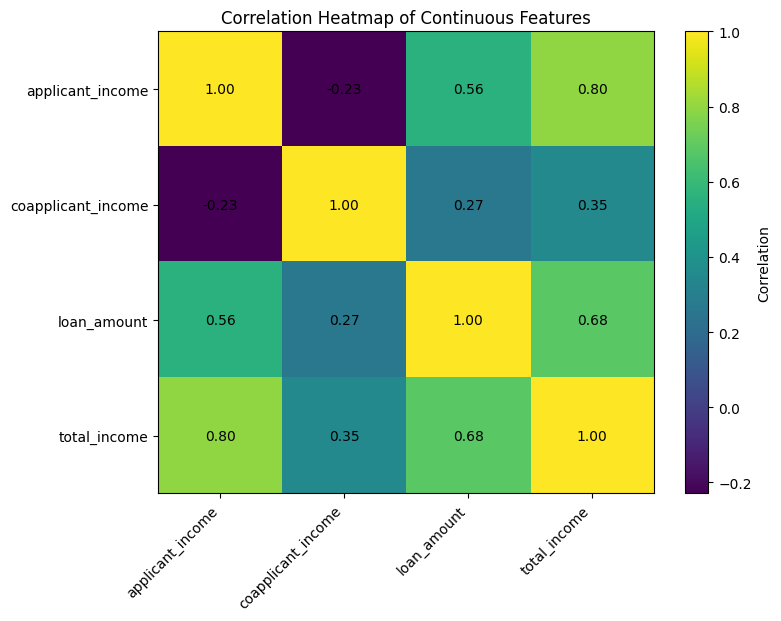

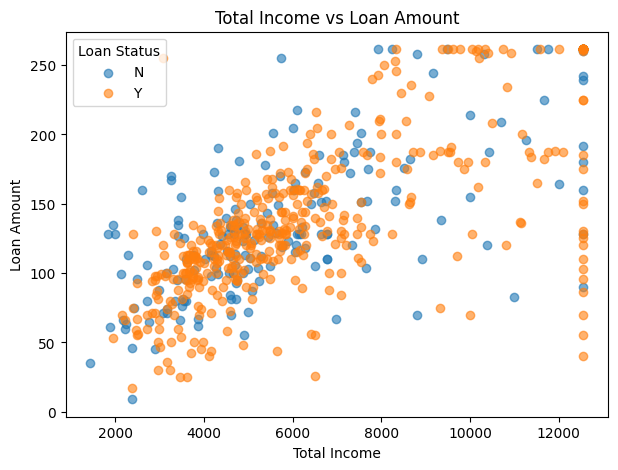

In [7]:
# 1. Loan status distribution
counts = df["loan_status"].value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values)
plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

# 2. Applicant income histogram
plt.figure(figsize=(7,5))
plt.hist(df["applicant_income"], bins=30)
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

# 3. Loan amount histogram
plt.figure(figsize=(7,5))
plt.hist(df["loan_amount"], bins=30)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

# 4. Loan amount box plot
groups = [df.loc[df["loan_status"] == s, "loan_amount"] for s in ["N", "Y"]]
plt.figure(figsize=(7,5))
plt.boxplot(groups, tick_labels=["N", "Y"])
plt.title("Loan Amount by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

# 5. Education vs loan status
edu = pd.crosstab(df["education"], df["loan_status"]).reindex(columns=["N","Y"], fill_value=0)
x = np.arange(len(edu.index))
width = 0.35
plt.figure(figsize=(7,5))
plt.bar(x-width/2, edu["N"], width, label="N")
plt.bar(x+width/2, edu["Y"], width, label="Y")
plt.xticks(x, edu.index)
plt.title("Loan Approval by Education")
plt.xlabel("Education")
plt.ylabel("Number of Applications")
plt.legend()
plt.show()

# 6. Credit history vs loan status
cred = pd.crosstab(df["credit_history"], df["loan_status"]).reindex(columns=["N","Y"], fill_value=0)
x = np.arange(len(cred.index))
plt.figure(figsize=(7,5))
plt.bar(x-width/2, cred["N"], width, label="N")
plt.bar(x+width/2, cred["Y"], width, label="Y")
plt.xticks(x, cred.index)
plt.title("Loan Approval by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applications")
plt.legend()
plt.show()

# 7. Correlation heatmap
corr = df[continuous_cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(continuous_cols)), continuous_cols, rotation=45, ha="right")
plt.yticks(range(len(continuous_cols)), continuous_cols)
for i in range(len(continuous_cols)):
    for j in range(len(continuous_cols)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
plt.title("Correlation Heatmap of Continuous Features")
plt.show()

# 8. Income vs loan amount
plt.figure(figsize=(7,5))
for status in ["N", "Y"]:
    subset = df[df["loan_status"] == status]
    plt.scatter(subset["total_income"], subset["loan_amount"], label=status, alpha=0.6)
plt.title("Total Income vs Loan Amount")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.legend(title="Loan Status")
plt.show()


## 9. Feature Encoding and Scaling

Categorical variables are encoded with **One-Hot Encoding** because several variables have more than two categories and the categories do not have a natural numerical order.

Continuous numerical variables are standardized using **StandardScaler** so their values are placed on a comparable scale.

`Credit_History` and `Loan_Amount_Term` are treated as discrete categorical variables rather than continuous measurements.


In [8]:
df_model = df.copy()
df_model["loan_status"] = df_model["loan_status"].map({"Y": 1, "N": 0})

X = df_model.drop(columns=["loan_status"])
y = df_model["loan_status"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), continuous_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols)
])

X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

ml_ready = pd.DataFrame(X_processed, columns=feature_names)
ml_ready["loan_status"] = y.values

print("ML-ready shape:", ml_ready.shape)
display(ml_ready.head())


ML-ready shape: (614, 32)


,num__applicant_income,num__coapplicant_income,num__loan_amount,num__total_income,cat__gender_Female,cat__gender_Male,cat__married_No,cat__married_Yes,cat__dependents_0,cat__dependents_1,cat__dependents_2,cat__dependents_3,cat__education_Graduate,cat__education_Not Graduate,cat__self_employed_No,cat__self_employed_Yes,cat__property_area_Rural,cat__property_area_Semiurban,cat__property_area_Urban,cat__loan_amount_term_12,cat__loan_amount_term_120,cat__loan_amount_term_180,cat__loan_amount_term_240,cat__loan_amount_term_300,cat__loan_amount_term_36,cat__loan_amount_term_360,cat__loan_amount_term_480,cat__loan_amount_term_60,cat__loan_amount_term_84,cat__credit_history_0,cat__credit_history_1,loan_status
0,0.497164,-0.874587,-0.168041,-0.120316,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
1,-0.013767,0.054395,-0.168041,-0.036097,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,-0.652632,-0.874587,-1.280462,-1.111808,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
3,-0.820924,0.578025,-0.311579,-0.436313,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
4,0.558104,-0.874587,0.065209,-0.067766,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1


## 10. Feature Selection

In [9]:
# Correlation among continuous variables
print("Continuous feature correlations:")
display(df[continuous_cols].corr().round(3))

# Random Forest feature importance
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train_p, y_train)

importance = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(15))


Continuous feature correlations:


,applicant_income,coapplicant_income,loan_amount,total_income
applicant_income,1.000,-0.229,0.558,0.796
coapplicant_income,-0.229,1.000,0.265,0.352
loan_amount,0.558,0.265,1.000,0.685
total_income,0.796,0.352,0.685,1.000


,feature,importance
3,num__total_income,0.139984
0,num__applicant_income,0.139579
2,num__loan_amount,0.135467
30,cat__credit_history_1,0.104588
29,cat__credit_history_0,0.098755
1,num__coapplicant_income,0.086187
17,cat__property_area_Semiurban,0.026399
8,cat__dependents_0,0.020432
16,cat__property_area_Rural,0.020041
9,cat__dependents_1,0.018864


### Feature Selection Interpretation

`Loan_ID` was removed because it is an identifier and does not represent a meaningful applicant characteristic.

`ApplicantIncome` and `CoapplicantIncome` are both retained because they provide distinct information, while `TotalIncome` is engineered to represent combined household/application income.

The correlation analysis shows that `TotalIncome` is strongly correlated with `ApplicantIncome` (approximately 0.80). This should be monitored for redundancy in a future modelling stage. The feature-importance analysis identifies total income, applicant income, loan amount, credit history, and coapplicant income among the stronger contributors to the predictive feature set.

No feature is removed solely because of correlation at this stage; the decision should ultimately be validated against the chosen machine-learning model and performance.


## 11. Export the Final Datasets

In [10]:
df.to_csv("../cleaned_loan_dataset.csv", index=False)
ml_ready.to_csv("../machine_learning_ready_loan_dataset.csv", index=False)

importance.to_csv("../feature_importance.csv", index=False)

print("Cleaned dataset saved.")
print("Machine-learning-ready dataset saved.")
print("Feature importance saved.")


Cleaned dataset saved.
Machine-learning-ready dataset saved.
Feature importance saved.


## 12. Conclusion

The Loan Prediction training dataset has been inspected and transformed into a machine-learning-ready format.

The workflow addressed missing values, duplicates, data-type handling, categorical encoding, numerical scaling, outlier detection and treatment, feature engineering, feature selection, and visualization.

The resulting ML-ready dataset is suitable as an input to a later predictive modelling stage, although model training and evaluation are outside the scope of this Week 2 preprocessing assignment.
